# Step 5: Model Evaluation

In this notebook, we compare the performance of the three models trained in Step 4:
1. Logistic Regression
2. Random Forest
3. Gradient Boosting

We evaluate them using Accuracy, Precision, Recall, and F1-score. We will also visualize their Confusion Matrices to see False Positives and False Negatives.


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load Features and Models
df = pd.read_csv('data/final_features.csv')
X = df.drop(columns=['cve_id', 'exploited'])
y = df['exploited']

# We must use the SAME random_state=42 train/test split to evaluate on the same test set!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load Models
lr_model = joblib.load('models/logistic_regression.pkl')
rf_model = joblib.load('models/random_forest.pkl')
gb_model = joblib.load('models/gradient_boosting.pkl')

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

print("Models loaded successfully.")


Models loaded successfully.


## Model Comparison Metrics

- **Accuracy**: Overall correctness of the model.
- **Precision**: How many predicted exploited vulnerabilities were actually exploited.
- **Recall**: How many actual exploited vulnerabilities did we correctly predict. 
- **F1 Score**: Harmonic mean of Precision and Recall.


In [2]:
metrics = []

for name, model in models.items():
    preds = model.predict(X_test)
    
    # Evaluate
    # Note: zero_division=0 prevents warnings if a model predicts only 0
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

# Convert to DataFrame for a nice comparative table
metrics_df = pd.DataFrame(metrics).set_index('Model')
display(metrics_df.round(4))


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.88,0.8788,0.7838,0.8286
Random Forest,0.93,0.9688,0.8378,0.8986
Gradient Boosting,0.92,0.8718,0.9189,0.8947


## Confusion Matrices

A Confusion Matrix helps visually understand:
- True Positives (Top Left: Predicted not exploited, Actual not exploited)
- False Positives (Top Right: Predicted exploited, Actual not exploited)
- False Negatives (Bottom Left: Predicted not exploited, Actual exploited)
- True Positives (Bottom Right: Predicted exploited, Actual exploited)


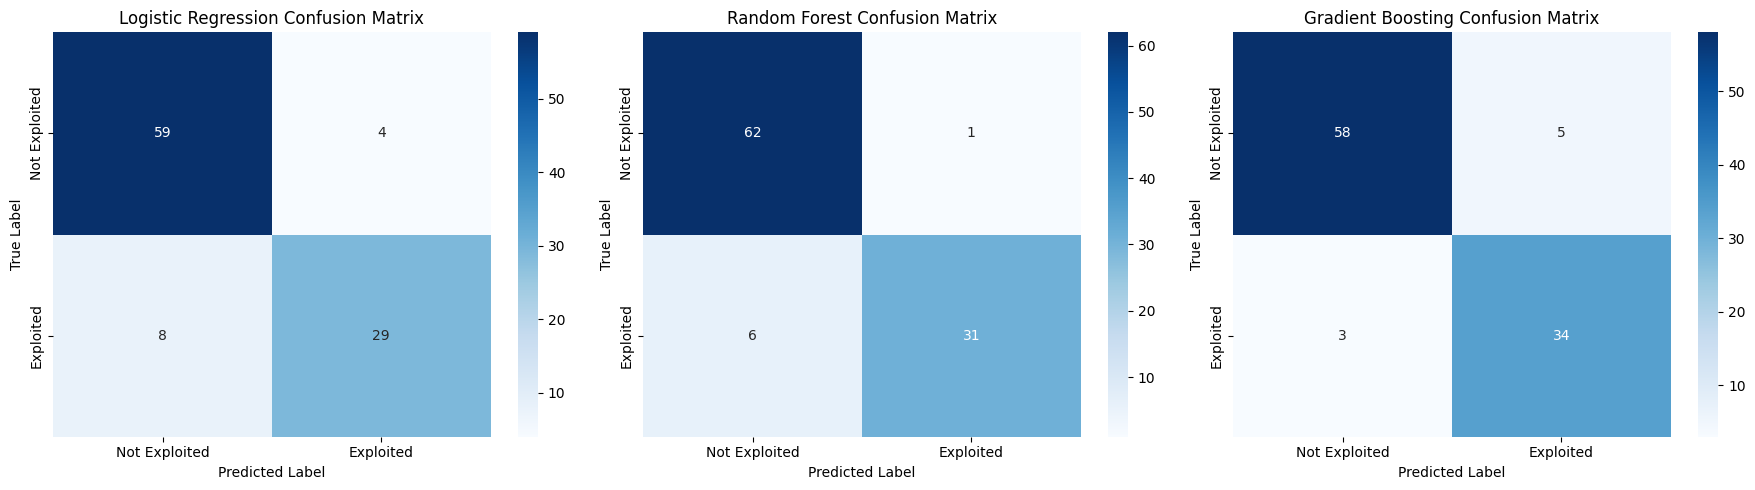

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.xaxis.set_ticklabels(['Not Exploited', 'Exploited'])
    ax.yaxis.set_ticklabels(['Not Exploited', 'Exploited'])

plt.tight_layout()
plt.show()
